# Análise Topográfica

## Imports

In [1]:
import ee
from IPython.display import Image
from dotenv import find_dotenv, load_dotenv
import os
import time

# PATHS

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)
project_root = os.path.dirname(dotenv_path)
KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print("Aviso: GOOGLE_APPLICATION_CREDENTIALS não encontrada no .env")

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Inicialização da API do Google Earth Engine

In [3]:
GCP_PROJECT = os.getenv("GCP_PROJECT_ID")
ee.Initialize(project=GCP_PROJECT)
print("API do Google Earth Engine inicializada com sucesso.")

API do Google Earth Engine inicializada com sucesso.


## Carreggamento dos dados

In [4]:
srtm = ee.Image("USGS/SRTMGL1_003")
fronteiras = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")

brasil = fronteiras.filter(ee.Filter.eq("country_co", "BR"))
srtm_brasil = srtm.clip(brasil)
declividade = ee.Terrain.slope(srtm_brasil)

## Inspeção dos dados

In [5]:
print("\nObtendo metadados da imagem de declividade...")
info_declividade = declividade.getInfo()
print("Metadados recebidos:")
print(f"  - Tipo do objeto: {info_declividade['type']}")
print(f"  - CRS da imagem: {info_declividade['bands'][0]['crs']}")


Obtendo metadados da imagem de declividade...
Metadados recebidos:
  - Tipo do objeto: Image
  - CRS da imagem: EPSG:4326


## Mapa topográfico do Brasil


Gerando URL de preview para o mapa de declividade...
URL gerada. Exibindo a imagem de preview:


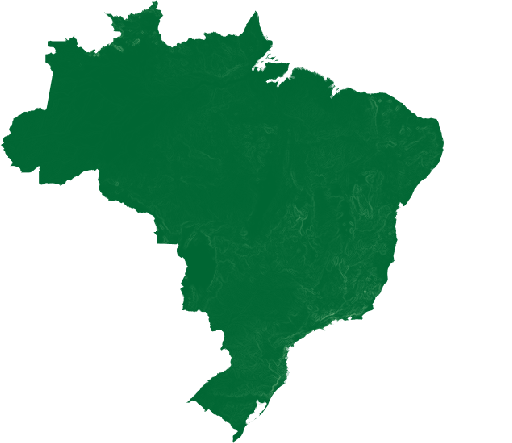

In [6]:
print("\nGerando URL de preview para o mapa de declividade...")
region = brasil.geometry()

declividadeParams = {
    "min": 0,
    "max": 45,
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8"],
    "region": region,
    "dimensions": 512,
}

url = declividade.getThumbURL(declividadeParams)
print("URL gerada. Exibindo a imagem de preview:")

display(Image(url=url, embed=True, format="png"))

## Exportação dos dados

In [8]:
print("\nConfigurando tarefa de exportação para o GCS...")
BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
FILE_PREFIX = "raw/topography/declividade_brasil_srtm_90m"
TASK_DESCRIPTION = "Export_Declividade_Brasil_90m_to_GCS"

region = brasil.geometry()

task = ee.batch.Export.image.toCloudStorage(
    image=declividade,
    description=TASK_DESCRIPTION,
    bucket=BUCKET_NAME,
    fileNamePrefix=FILE_PREFIX,
    scale=90,
    region=region,
    maxPixels=1e13,
)

# Iniciar a tarefa de exportação
task.start()

print(f"\nTarefa '{TASK_DESCRIPTION}' iniciada com sucesso.")
print("Monitorando o status da tarefa (verificando a cada 30 segundos)...")

while task.active():
    print(f"Status: {task.status()['state']}")
    time.sleep(30)

final_status = task.status()
print(f"Tarefa concluída com o status: {final_status['state']}")
if final_status["state"] == "FAILED":
    print(f"  Erro: {final_status['error_message']}")

print(
    f"\nOs arquivos GeoTIFF (.tif) foram salvos em 'gs://{BUCKET_NAME}/{FILE_PREFIX}-...'"
)


Configurando tarefa de exportação para o GCS...

Tarefa 'Export_Declividade_Brasil_90m_to_GCS' iniciada com sucesso.
Monitorando o status da tarefa (verificando a cada 30 segundos)...
Status: READY
Status: READY
Status: READY
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Statu

KeyboardInterrupt: 